In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import warnings
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
 
from scipy.stats import loguniform,pointbiserialr
 
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, RandomizedSearchCV, cross_val_predict
)
from sklearn.preprocessing import (
    LabelEncoder, StandardScaler,
    OrdinalEncoder, OneHotEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report,
    roc_auc_score, f1_score, matthews_corrcoef,
    make_scorer, average_precision_score,
    precision_recall_curve, confusion_matrix
)
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
 
from catboost import CatBoostClassifier, Pool
from sklearn.feature_selection import mutual_info_classif

from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier
)

from sklearn.utils.class_weight import compute_sample_weight

from sklearn.metrics import (
    precision_score,
    recall_score
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
warnings.filterwarnings("ignore")
 
ibmchurn = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "pavansubhasht/ibm-hr-analytics-attrition-dataset",
    "WA_Fn-UseC_-HR-Employee-Attrition.csv",
)

                           dtype  missing  n_unique
EmployeeCount              int64        0         1
Over18                    object        0         1
StandardHours              int64        0         1
Attrition                 object        0         2
OverTime                  object        0         2
PerformanceRating          int64        0         2
Gender                    object        0         2
Attrition_bin              int64        0         2
Department                object        0         3
MaritalStatus             object        0         3
BusinessTravel            object        0         3
RelationshipSatisfaction   int64        0         4
JobSatisfaction            int64        0         4
EnvironmentSatisfaction    int64        0         4
JobInvolvement             int64        0         4

Near-constant columns:
                    dtype  missing  n_unique
Attrition          object        0         2
EmployeeCount       int64        0         1
Gender   

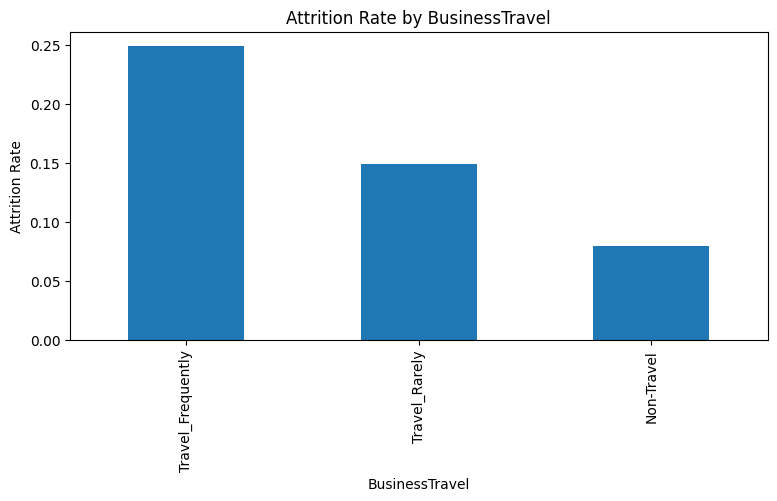

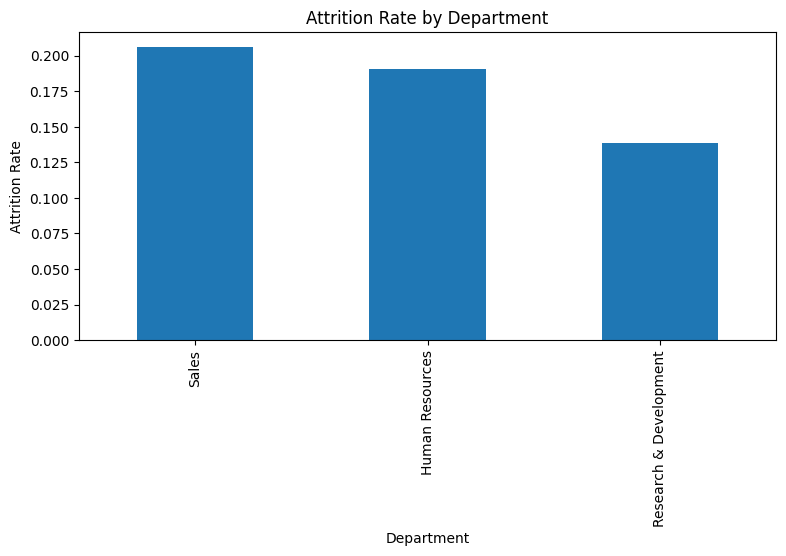

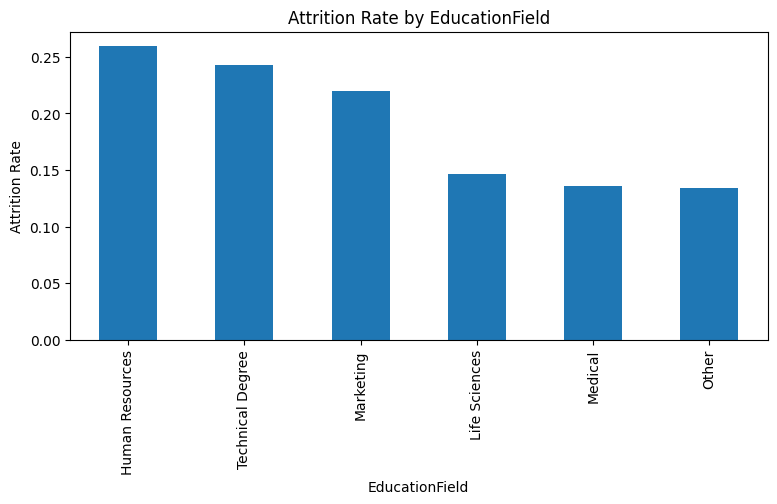

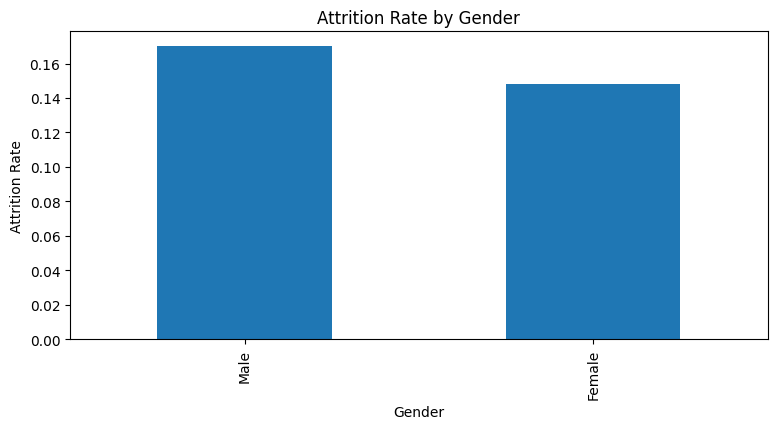

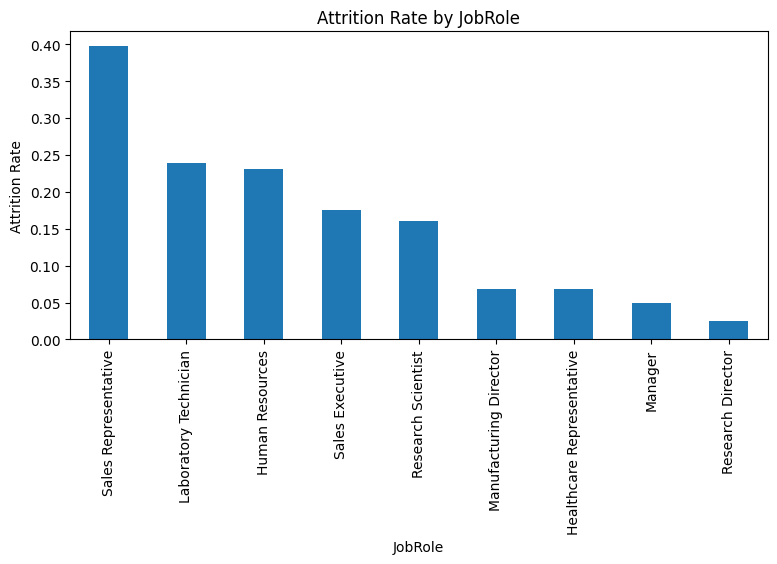

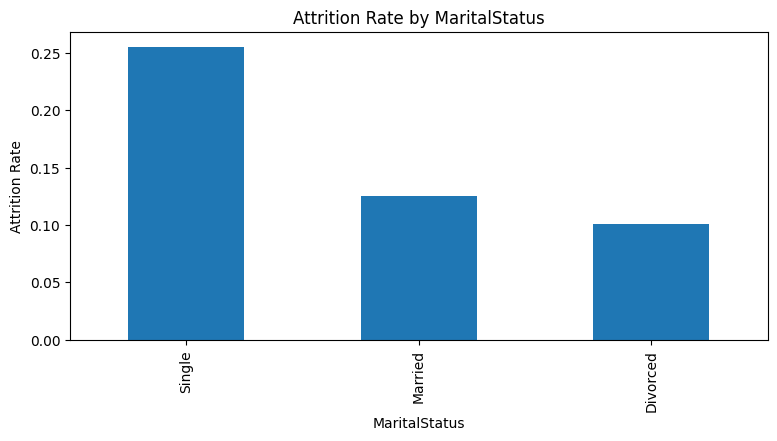

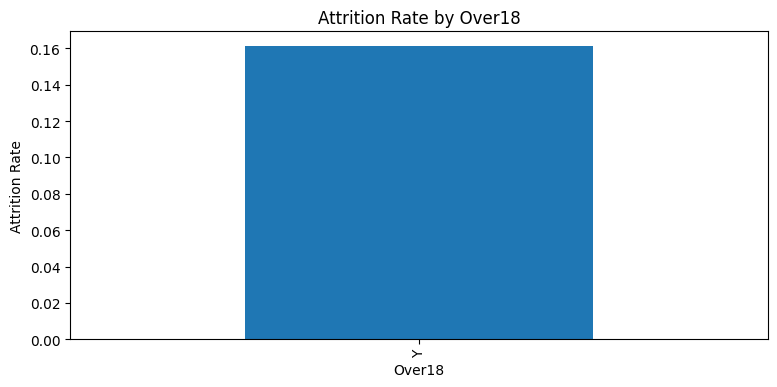

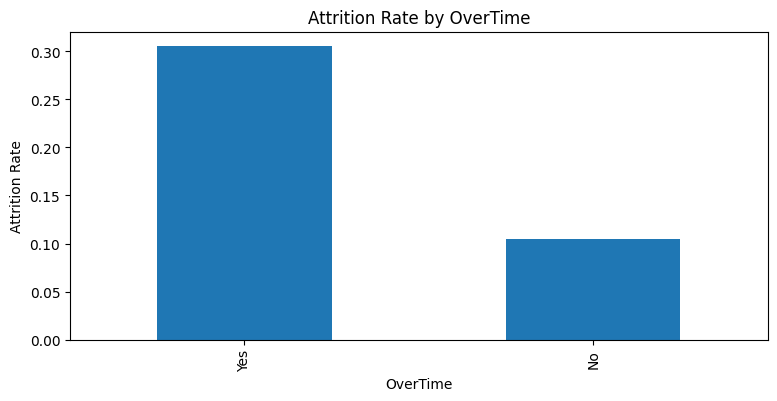

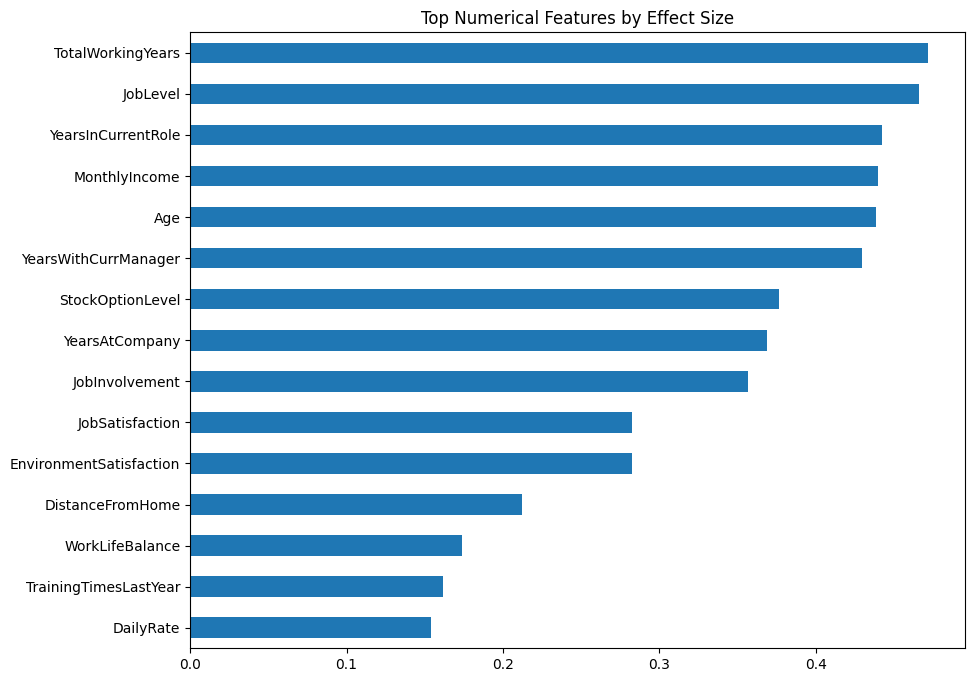

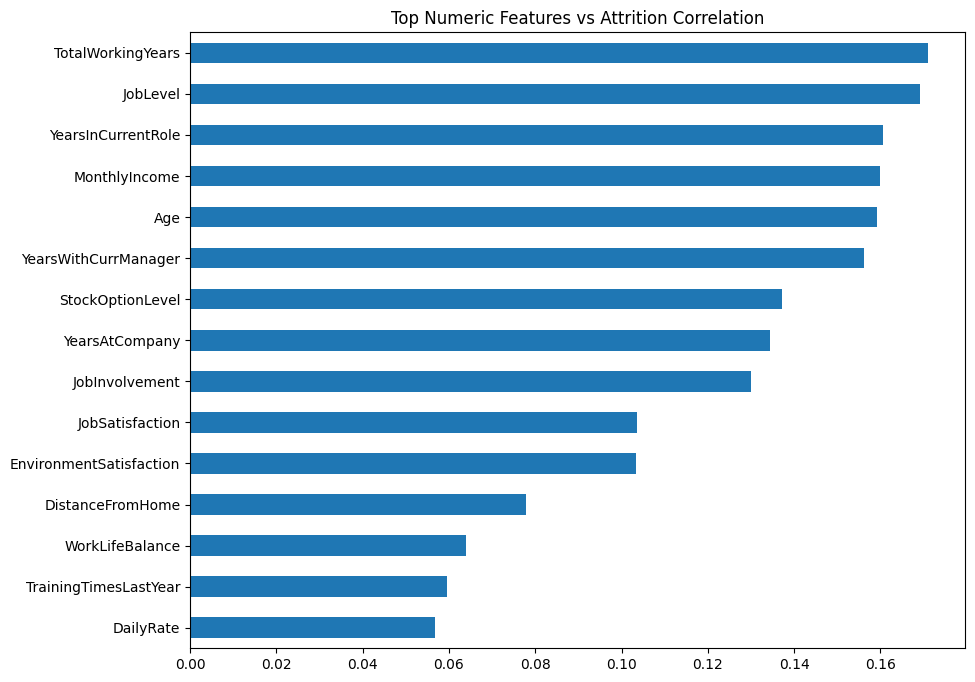

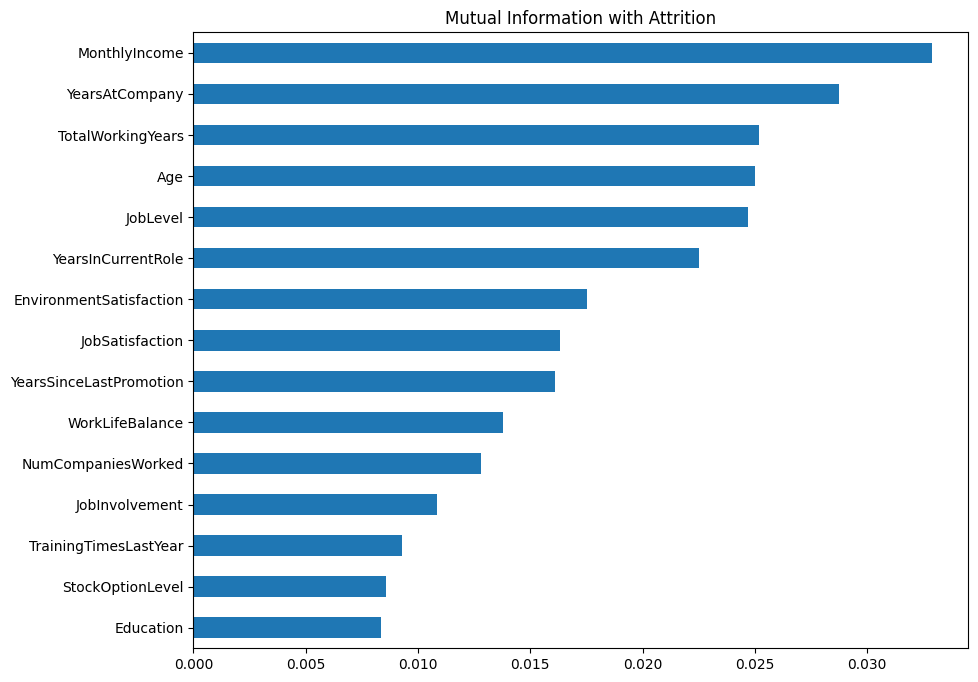


Highly correlated features:
['MonthlyIncome']


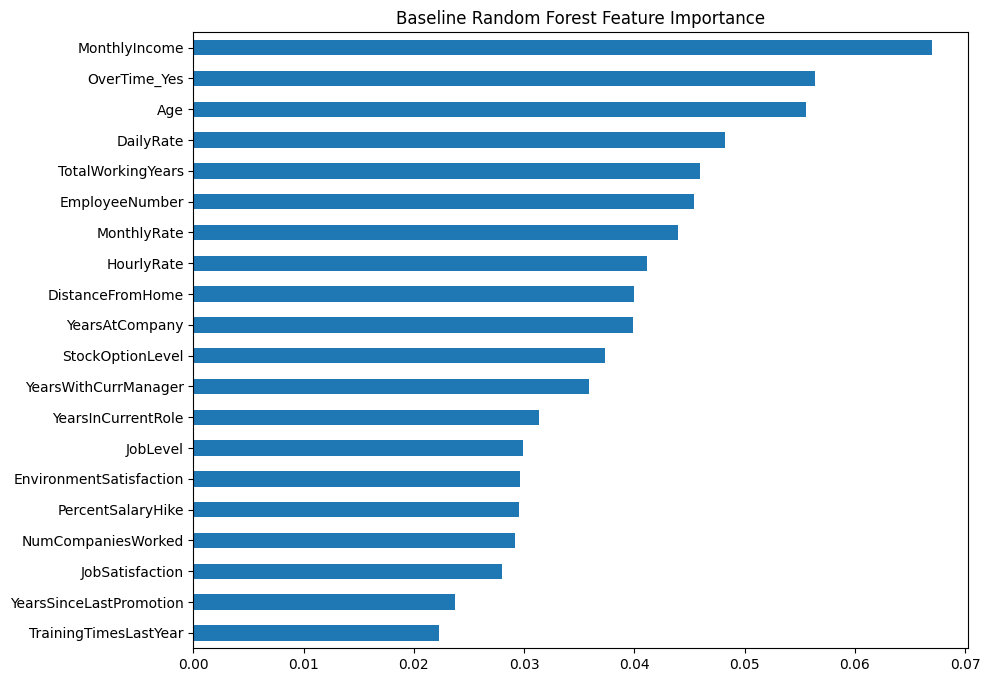

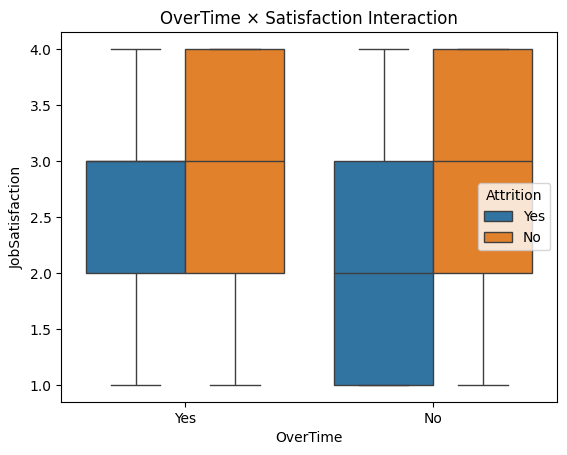

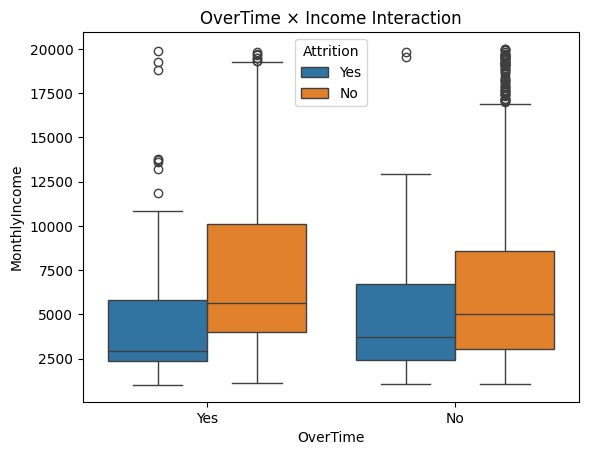

In [ ]:


df_eda = ibmchurn.copy()
df_eda['Attrition_bin'] = LabelEncoder().fit_transform(df_eda['Attrition'])


eda_cat_cols = ibmchurn.select_dtypes(include="object").columns
eda_num_cols = ibmchurn.select_dtypes(exclude="object").columns

summary = pd.DataFrame({
    "dtype": df_eda.dtypes,
    "missing": df_eda.isnull().sum(),
    "n_unique": df_eda.nunique()
})

print(summary.sort_values("n_unique").head(15))

# Near-zero variance candidates
print("\nNear-constant columns:")
print(summary[summary['n_unique']<=2])


### Attrition rate by categorical subgroup ###

for col in eda_cat_cols:
    
    if col != 'Attrition':
        attr_rate = (
            df_eda.groupby(col)['Attrition_bin']
            .mean()
            .sort_values(ascending=False)
        )
        
        plt.figure(figsize=(9,4))
        attr_rate.plot(kind='bar')
        plt.ylabel("Attrition Rate")
        plt.title(f"Attrition Rate by {col}")
        plt.show()


### Numeric effect size (Cohen's d) ####

def cohens_d(a,b):
    pooled=np.sqrt(
        ((len(a)-1)*a.var() + (len(b)-1)*b.var())/
        (len(a)+len(b)-2)
    )
    return (a.mean()-b.mean())/pooled

effect_sizes={}

for col in eda_num_cols:
    
    if col not in ['EmployeeCount','EmployeeNumber','StandardHours']:
        
        left = df_eda[df_eda.Attrition=="Yes"][col]
        stay = df_eda[df_eda.Attrition=="No"][col]
        
        effect_sizes[col]=abs(cohens_d(left,stay))

effect_sizes=pd.Series(effect_sizes).sort_values()

plt.figure(figsize=(10,8))
effect_sizes.tail(15).plot(kind='barh')
plt.title("Top Numerical Features by Effect Size")
plt.show()


### Point-biserial correlations with target ###

corrs={}

for col in eda_num_cols:
    
    if col not in ['EmployeeCount','EmployeeNumber','StandardHours']:
        corr,_=pointbiserialr(
            df_eda['Attrition_bin'],
            df_eda[col]
        )
        corrs[col]=abs(corr)

corrs=pd.Series(corrs).sort_values()

plt.figure(figsize=(10,8))
corrs.tail(15).plot(kind='barh')
plt.title("Top Numeric Features vs Attrition Correlation")
plt.show()

### Mutual Information ranking ####

X_num = df_eda[
    [c for c in eda_num_cols
    if c not in ['EmployeeCount','EmployeeNumber','StandardHours']]
]

mi = mutual_info_classif(
    X_num,
    df_eda['Attrition_bin'],
    random_state=42
)

mi=pd.Series(mi,index=X_num.columns).sort_values()

plt.figure(figsize=(10,8))
mi.tail(15).plot(kind='barh')
plt.title("Mutual Information with Attrition")
plt.show()


###  Multicollinearity check ###

corr_matrix=X_num.corr().abs()

upper=corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape),k=1).astype(bool)
)

high_corr=[
    c for c in upper.columns
    if any(upper[c]>0.80)
]

print("\nHighly correlated features:")
print(high_corr)


### Baseline feature importance sanity check ####

X_rf=pd.get_dummies(
    df_eda.drop(columns=['Attrition','Attrition_bin']),
    drop_first=True
)

rf=RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_rf,df_eda['Attrition_bin'])

imp=pd.Series(
    rf.feature_importances_,
    index=X_rf.columns
).sort_values()

plt.figure(figsize=(10,8))
imp.tail(20).plot(kind='barh')
plt.title("Baseline Random Forest Feature Importance")
plt.show()


### Interaction sanity plots ###

sns.boxplot(
    data=df_eda,
    x='OverTime',
    y='JobSatisfaction',
    hue='Attrition'
)
plt.title("OverTime × Satisfaction Interaction")
plt.show()

sns.boxplot(
    data=df_eda,
    x='OverTime',
    y='MonthlyIncome',
    hue='Attrition'
)
plt.title("OverTime × Income Interaction")
plt.show()

In [ ]:
def feature_engineering(df, train_income_median=None):
    df = df.copy()
 
    df["PromotionLag"]     = df["YearsSinceLastPromotion"] / (df["YearsAtCompany"] + 1)
    df["ManagerStability"] = df["YearsWithCurrManager"]    / (df["YearsAtCompany"] + 1)
    df["RoleLock"]         = df["YearsInCurrentRole"]      / (df["YearsAtCompany"] + 1)
    df["IncomePerLevel"]   = df["MonthlyIncome"]           / (df["JobLevel"] + 1)
 
    median = train_income_median if train_income_median is not None else df["MonthlyIncome"].median()
    df["LowIncomeFlag"] = (df["MonthlyIncome"] < median).astype(int)
 
    df["OverTime_enc"]        = (df["OverTime"] == "Yes").astype(int)
    df["OvertimeStress"]      = df["OverTime_enc"] * (5 - df["JobSatisfaction"])
    df["OvertimeWorkLife"]    = df["OverTime_enc"] * (5 - df["WorkLifeBalance"])
    df["OvertimeEnvironment"] = df["OverTime_enc"] * (5 - df["EnvironmentSatisfaction"])
 
    df["LowStockOption"] = (df["StockOptionLevel"] == 0).astype(int)
    df["EarlyCareer"]    = ((df["Age"] < 35) & (df["TotalWorkingYears"] < 10)).astype(int)
 

    df["SatisfactionScore"] = (
        df["JobSatisfaction"] +
        df["EnvironmentSatisfaction"] +
        df["WorkLifeBalance"] +
        df["RelationshipSatisfaction"]
    )
 
    df["TenureAgeRatio"]    = df["YearsAtCompany"] / (df["Age"] + 1)
   
    df["DistanceOvertime"]  = df["DistanceFromHome"] * df["OverTime_enc"]

    df["StagnationRisk"]    = df["PromotionLag"] * df["LowIncomeFlag"]
 
    df = df.drop(columns=["OverTime"])
    return df
 
 

In [ ]:

df_base = ibmchurn.drop(columns=["EmployeeCount", "EmployeeNumber", "StandardHours", "Over18"])
 
y_all = LabelEncoder().fit_transform(df_base["Attrition"])
X_all = df_base.drop(columns=["Attrition"])
 
X_tr_raw, X_te_raw, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)
 
train_income_median = X_tr_raw["MonthlyIncome"].median()
X_train = feature_engineering(X_tr_raw, train_income_median=train_income_median)
X_test  = feature_engineering(X_te_raw, train_income_median=train_income_median)
 
neg, pos = np.bincount(y_train)
imbalance_ratio = neg / pos
print(f"Class distribution — Majority: {neg}, Minority: {pos}, Ratio: {imbalance_ratio:.2f}")

Class distribution — Majority: 986, Minority: 190, Ratio: 5.19


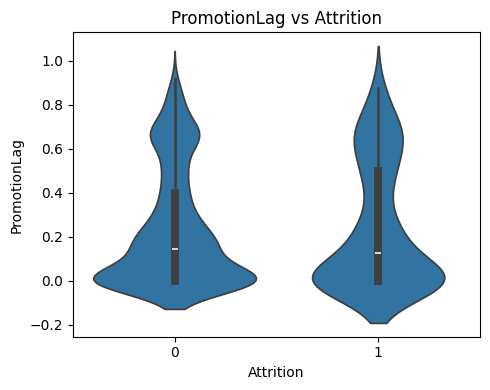

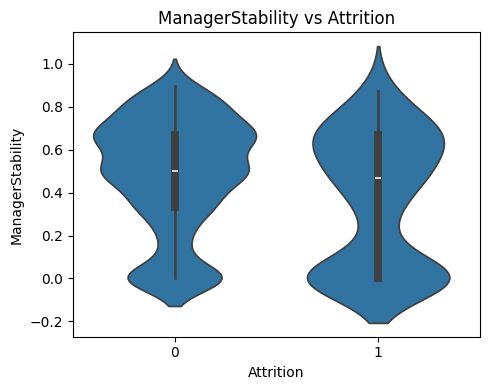

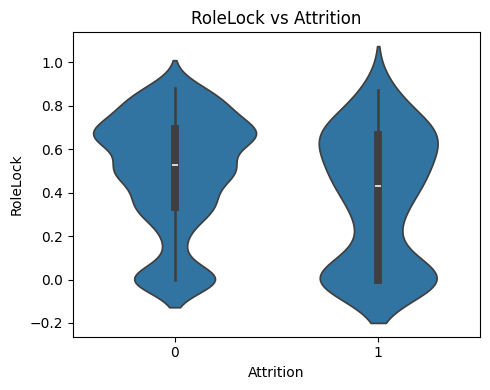

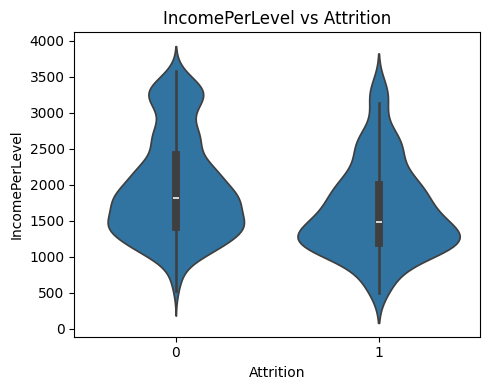

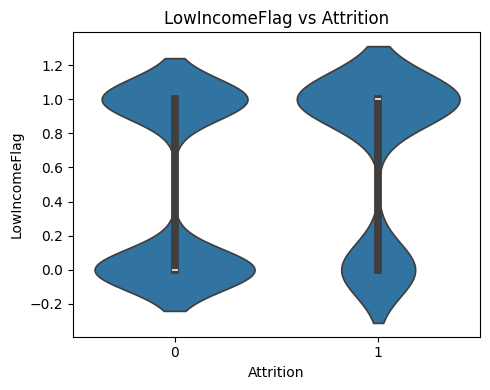

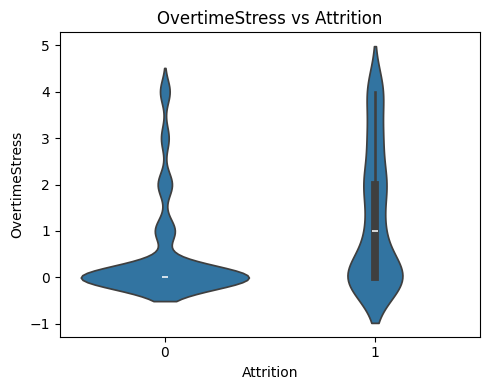

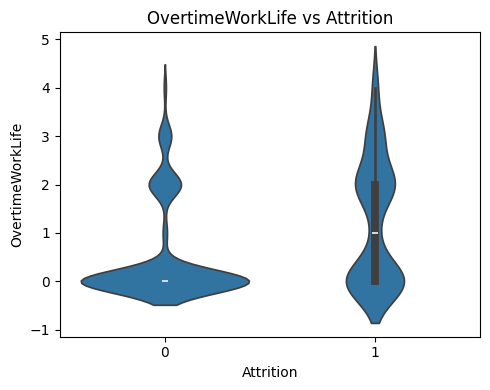

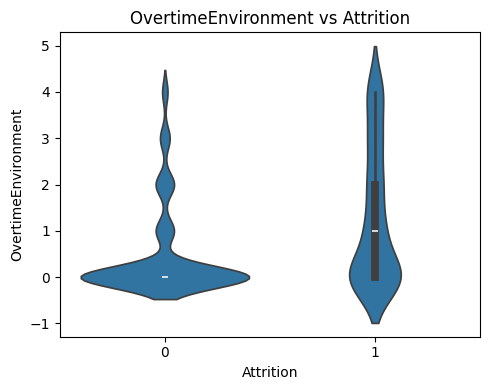

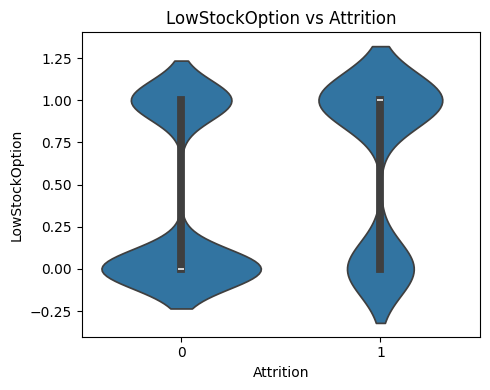

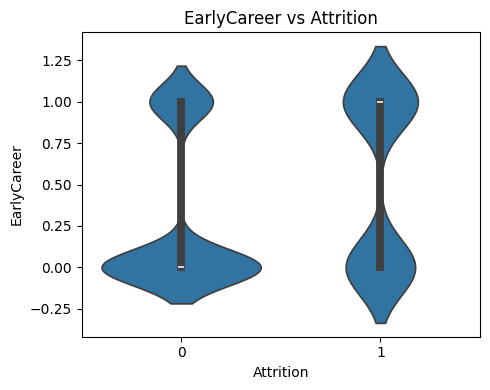

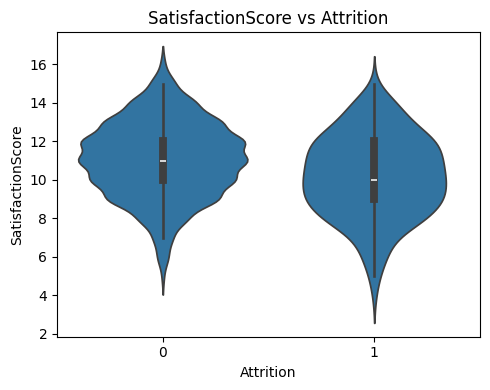

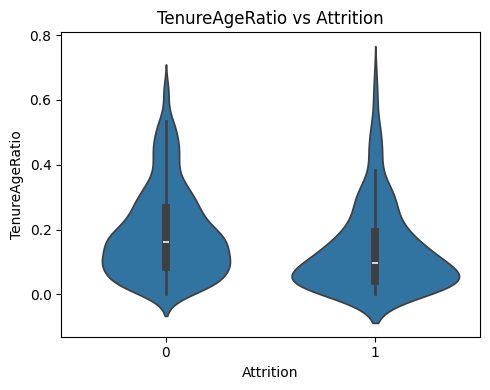

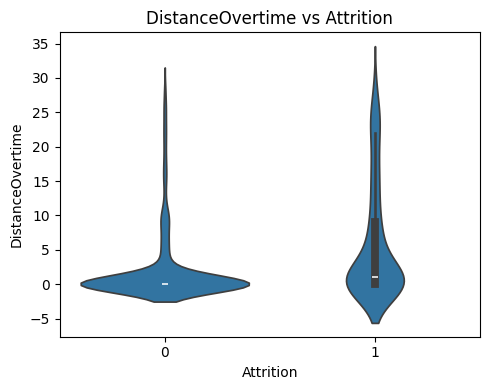

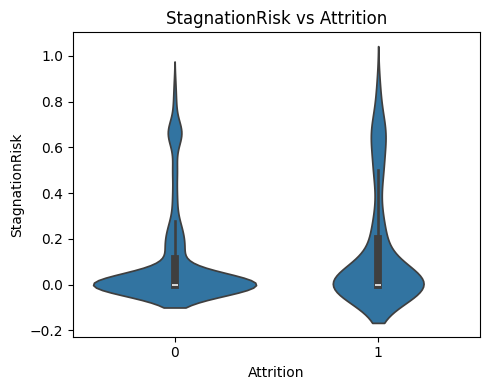


=== ENGINEERED FEATURE EFFECT SIZE (HIGH → GOOD) ===
OvertimeEnvironment    0.650292
OvertimeStress         0.634054
OvertimeWorkLife       0.619486
DistanceOvertime       0.554315
LowStockOption         0.544748
EarlyCareer            0.491532
IncomePerLevel         0.486243
LowIncomeFlag          0.437189
SatisfactionScore      0.426687
RoleLock               0.416191
ManagerStability       0.399800
TenureAgeRatio         0.385076
StagnationRisk         0.202710
PromotionLag           0.027580
dtype: float64

=== LOW OVERLAP ===
DistanceOvertime       0.694642
OvertimeEnvironment    0.698523
OvertimeStress         0.698523
OvertimeWorkLife       0.698523
LowStockOption         0.737072
ManagerStability       0.737715
IncomePerLevel         0.744199
TenureAgeRatio         0.744854
RoleLock               0.751822
EarlyCareer            0.765684
dtype: float64

=== HIGH OVERLAP ===
LowStockOption       0.737072
ManagerStability     0.737715
IncomePerLevel       0.744199
TenureAgeRatio 

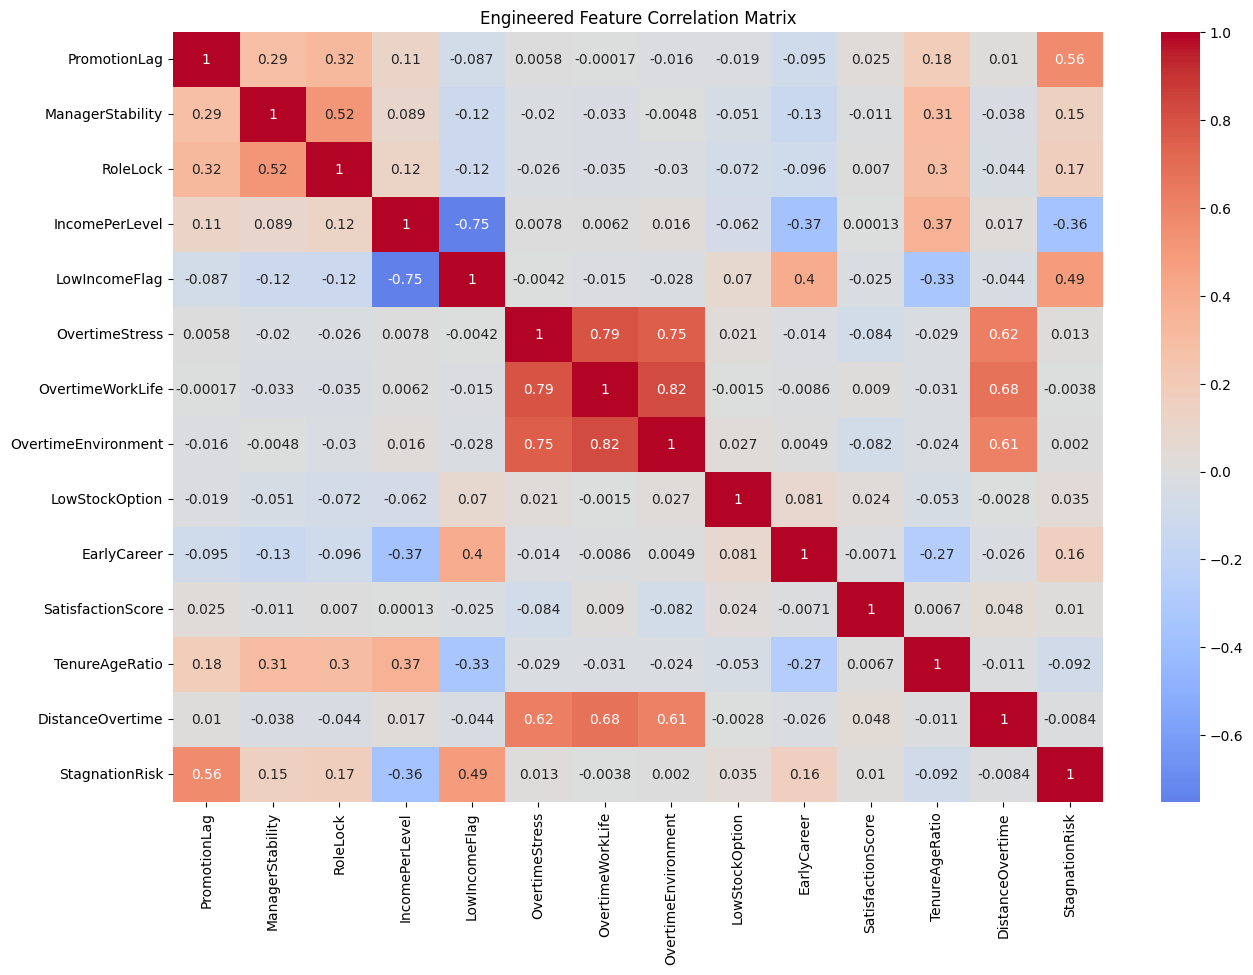


=== FEATURES MORE ACTIVE IN MINORITY CLASS ===
DistanceOvertime       2.562246
OvertimeEnvironment    2.246151
OvertimeStress         1.908894
OvertimeWorkLife       1.623485
StagnationRisk         1.444171
ManagerStability       1.346289
RoleLock               1.265010
EarlyCareer            1.230121
SatisfactionScore      1.161101
PromotionLag           1.159319
dtype: float64


In [ ]:


df_eng = pd.concat([X_train, X_test], axis=0).copy()
y_eng  = np.concatenate([y_train, y_test])

df_eng['Attrition'] = y_eng

#### Visual Class Separation of Engineered Features ####
engineered_cols = [
    'PromotionLag', 'ManagerStability', 'RoleLock',
    'IncomePerLevel', 'LowIncomeFlag',
    'OvertimeStress', 'OvertimeWorkLife', 'OvertimeEnvironment',
    'LowStockOption', 'EarlyCareer',
    'SatisfactionScore', 'TenureAgeRatio',
    'DistanceOvertime', 'StagnationRisk'
]

for col in engineered_cols:
    if col not in df_eng.columns:
        continue
    plt.figure(figsize=(5,4))
    sns.violinplot(data=df_eng, x='Attrition', y=col)
    plt.title(f"{col} vs Attrition")
    plt.tight_layout()
    plt.show()


### Effect Size  ###

def cohen_d(x1, x2):
    return (x1.mean() - x2.mean()) / np.sqrt((x1.var() + x2.var()) / 2 + 1e-9)

effect_sizes = {}

minority = df_eng[df_eng['Attrition'] == 1]
majority = df_eng[df_eng['Attrition'] == 0]

for col in engineered_cols:
    if col not in df_eng.columns:
        continue
    d = cohen_d(minority[col], majority[col])
    effect_sizes[col] = abs(d)

effect_df = pd.Series(effect_sizes).sort_values(ascending=False)

print("\n=== ENGINEERED FEATURE EFFECT SIZE (HIGH → GOOD) ===")
print(effect_df)


###  Overlap Score ###

def overlap_score(x1, x2, bins=50):
    hist1, bins = np.histogram(x1, bins=bins, density=True)
    hist2, _    = np.histogram(x2, bins=bins, density=True)
    return np.sum(np.minimum(hist1, hist2)) / np.sum(hist1)

overlap = {}

for col in engineered_cols:
    if col not in df_eng.columns:
        continue
    overlap[col] = overlap_score(minority[col], majority[col])

overlap_df = pd.Series(overlap).sort_values()

print("\n=== LOW OVERLAP ===")
print(overlap_df.head(10))

print("\n=== HIGH OVERLAP ===")
print(overlap_df.tail(10))


### Correlation with Target ###
corr = df_eng.corr(numeric_only=True)['Attrition'].sort_values(ascending=False)

print("\n=== ENGINEERED FEATURE CORRELATION ===")
print(corr.loc[engineered_cols].sort_values(ascending=False))


### Redundancy Check ###


corr_matrix = df_eng[engineered_cols].corr()

plt.figure(figsize=(15,10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0,annot=True)
plt.title("Engineered Feature Correlation Matrix")
plt.show()


### Minority-Specific Signal Strength  ###

minority_variance = minority[engineered_cols].var()
majority_variance = majority[engineered_cols].var()

ratio = (minority_variance + 1e-9) / (majority_variance + 1e-9)

ratio = ratio.sort_values(ascending=False)

print("\n=== FEATURES MORE ACTIVE IN MINORITY CLASS ===")
print(ratio.head(10))

In [ ]:
### Preprocessing ###
ORDINAL_COLS = [
    "Education", "EnvironmentSatisfaction", "JobInvolvement",
    "JobLevel", "JobSatisfaction", "PerformanceRating",
    "RelationshipSatisfaction", "StockOptionLevel", "WorkLifeBalance",
]
ORDINAL_CATEGORIES = {
    "Education":               [1, 2, 3, 4, 5],
    "EnvironmentSatisfaction": [1, 2, 3, 4],
    "JobInvolvement":          [1, 2, 3, 4],
    "JobLevel":                [1, 2, 3, 4, 5],
    "JobSatisfaction":         [1, 2, 3, 4],
    "PerformanceRating":       [1, 2, 3, 4],
    "RelationshipSatisfaction":[1, 2, 3, 4],
    "StockOptionLevel":        [0, 1, 2, 3],
    "WorkLifeBalance":         [1, 2, 3, 4],
}
ordinal_categories_list = [ORDINAL_CATEGORIES[c] for c in ORDINAL_COLS]
 
feature_cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
all_numeric_cols = X_train.select_dtypes(exclude=["object"]).columns.tolist()
feature_num_cols = [c for c in all_numeric_cols if c not in ORDINAL_COLS]
 
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), feature_num_cols),
    ("ord", OrdinalEncoder(categories=ordinal_categories_list), ORDINAL_COLS),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), feature_cat_cols),
])
 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)


In [ ]:

 
def evaluate(y_true, preds, proba, label="Model"):
    """Print full metric set including PR-AUC."""
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    print(f"  Accuracy  : {accuracy_score(y_true, preds):.4f}")
    print(f"  ROC-AUC   : {roc_auc_score(y_true, proba):.4f}")
    print(f"  PR-AUC    : {average_precision_score(y_true, proba):.4f}")
    print(f"  F1 (Yes)  : {f1_score(y_true, preds, pos_label=1):.4f}")
    print(f"  MCC       : {matthews_corrcoef(y_true, preds):.4f}")
    print(classification_report(y_true, preds, target_names=["Stayed", "Left"]))
 
 
def threshold_search(y_true, proba, metric="f1", lo=0.05, hi=0.80, steps=300):
    """
    Scan thresholds; return (best_threshold, best_score).
    Optimise F1 of minority class by default — more stable than MCC for
    small test sets where MCC can spike on a single prediction flip.
    """
    thresholds = np.linspace(lo, hi, steps)
    best_thr, best_score = 0.5, -1.0
    for thr in thresholds:
        preds = (proba >= thr).astype(int)
        score = (f1_score(y_true, preds, pos_label=1)
                 if metric == "f1"
                 else matthews_corrcoef(y_true, preds))
        if score > best_score:
            best_score, best_thr = score, thr
    return best_thr, best_score
 
 
def oof_threshold_calibration(estimator, X, y, cv, metric="f1"):
    """
    Calibrate decision threshold using OOF probabilities — no leakage,
    uses all training data. estimator must implement predict_proba.
    """
    oof_proba = np.zeros(len(y))
    for tr_idx, val_idx in cv.split(X, y):
        clone = type(estimator)(**estimator.get_params())
        clone.fit(X.iloc[tr_idx], y[tr_idx])
        oof_proba[val_idx] = clone.predict_proba(X.iloc[val_idx])[:, 1]
    opt_thr, opt_score = threshold_search(y, oof_proba, metric=metric)
    return opt_thr, opt_score, oof_proba
 
 


 RandomForest
              precision    recall  f1-score   support

      Stayed       0.85      0.99      0.92       247
        Left       0.62      0.11      0.18        47

    accuracy                           0.85       294
   macro avg       0.74      0.55      0.55       294
weighted avg       0.82      0.85      0.80       294


 XGBoost
              precision    recall  f1-score   support

      Stayed       0.87      0.96      0.92       247
        Left       0.57      0.28      0.37        47

    accuracy                           0.85       294
   macro avg       0.72      0.62      0.64       294
weighted avg       0.83      0.85      0.83       294


 LightGBM
[LightGBM] [Info] Number of positive: 190, number of negative: 986
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000421 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info]

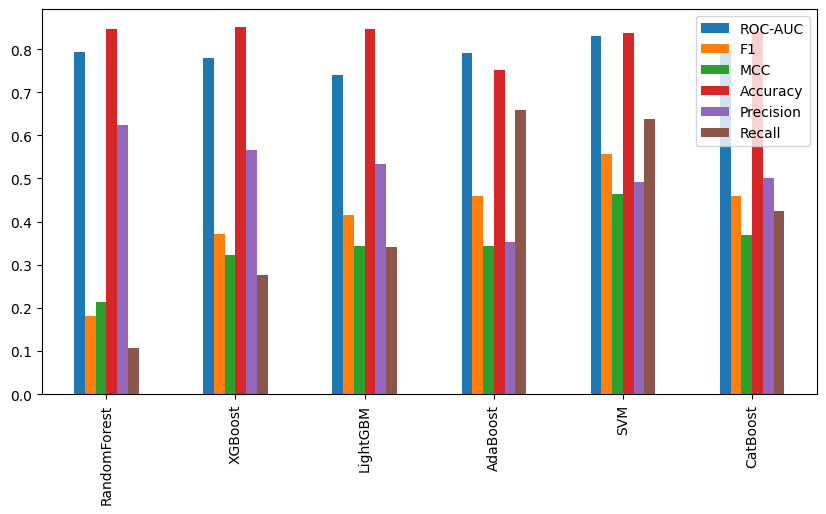

In [ ]:

### Models Baseline  Comparison ###

neg,pos=np.bincount(y_train)
ratio=neg/pos

sample_weights=compute_sample_weight(
"balanced",
y_train
)

models={

"RandomForest":
RandomForestClassifier(
class_weight="balanced",
random_state=42
),

"XGBoost":
XGBClassifier(
scale_pos_weight=ratio,
eval_metric="logloss",
random_state=42
),

"LightGBM":
LGBMClassifier(
class_weight="balanced",
random_state=42
),

"AdaBoost":
AdaBoostClassifier(
random_state=42
),

"SVM":
SVC(
class_weight="balanced",
kernel="rbf",
probability=True,
random_state=42
),

"CatBoost":
CatBoostClassifier(
auto_class_weights="Balanced",
verbose=0,
random_state=42
)

}


cv=StratifiedKFold(
n_splits=5,
shuffle=True,
random_state=42
)

results={}

for name,model in models.items():

    print("\n",name)

    if name=="AdaBoost":
        model.fit(
        X_train_proc,
        y_train,
        sample_weight=sample_weights
        )

        preds=model.predict(X_test_proc)
        proba=model.predict_proba(X_test_proc)[:,1]

    elif name=="CatBoost":

        cat_idx=[
        X_train.columns.get_loc(c)
        for c in feature_cat_cols
        ]

        tr_pool=Pool(
        X_train,y_train,
        cat_features=cat_idx
        )

        te_pool=Pool(
        X_test,y_test,
        cat_features=cat_idx
        )

        model.fit(tr_pool)
        preds=model.predict(te_pool)
        proba=model.predict_proba(te_pool)[:,1]

    else:

        model.fit(
        X_train_proc,
        y_train
        )
        preds=model.predict(X_test_proc)
        proba=model.predict_proba(X_test_proc)[:,1]


    print(
classification_report(
y_test,
preds,
target_names=["Stayed","Left"]
)
)

    results[name]={
    "ROC-AUC":roc_auc_score(y_test,proba),
    "F1":f1_score(y_test,preds,pos_label=1),
    "MCC":matthews_corrcoef(y_test,preds),
     "Accuracy":accuracy_score(y_test,preds)
    ,"Precision":precision_score(y_test,preds),
    "Recall":recall_score(y_test,preds)
    }


pd.DataFrame(results).T.plot(
kind="bar",
figsize=(10,5)
)
plt.show()

In [ ]:
cat_features_idx = [X_train.columns.get_loc(col) for col in feature_cat_cols]
 
train_pool = Pool(X_train, y_train, cat_features=cat_features_idx)
test_pool  = Pool(X_test,  y_test,  cat_features=cat_features_idx)
shap_model = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="F1",
    auto_class_weights="Balanced",
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_state=42,
    verbose=0,
)
shap_model.fit(train_pool)
 
shap_vals = shap_model.get_feature_importance(train_pool, type="ShapValues")
shap_importance = pd.Series(
    np.abs(shap_vals[:, :-1]).mean(axis=0),
    index=X_train.columns
).sort_values(ascending=False)
 
minority_mask = y_train == 1
shap_minority = pd.Series(
    np.abs(shap_vals[minority_mask, :-1]).mean(axis=0),
    index=X_train.columns
).sort_values(ascending=False)
 
print("\nTop-20 SHAP importance (global):")
print(shap_importance.head(20).to_string())
print("\nTop-20 SHAP importance (minority class only):")
print(shap_minority.head(20).to_string())
 
top_global   = set(shap_importance.head(20).index)
top_minority = set(shap_minority.head(20).index)
selected_cols = list(top_global | top_minority)
selected_cols = [c for c in X_train.columns if c in selected_cols]
print(f"\n{len(selected_cols)} features selected via SHAP union.")
 


Top-20 SHAP importance (global):
JobRole                    0.440481
NumCompaniesWorked         0.344107
Age                        0.331155
SatisfactionScore          0.330713
StockOptionLevel           0.305139
DistanceFromHome           0.244722
BusinessTravel             0.243539
DailyRate                  0.232104
OvertimeStress             0.221648
EnvironmentSatisfaction    0.204965
DistanceOvertime           0.203884
ManagerStability           0.180378
OvertimeEnvironment        0.174939
MonthlyIncome              0.161650
TenureAgeRatio             0.153649
JobInvolvement             0.150381
Department                 0.143242
LowStockOption             0.139297
JobSatisfaction            0.134423
RoleLock                   0.133971

Top-20 SHAP importance (minority class only):
JobRole                    0.559892
Age                        0.496142
SatisfactionScore          0.429361
StockOptionLevel           0.359455
NumCompaniesWorked         0.358253
OvertimeStress     

In [ ]:

svc_pipe = Pipeline([
    ("pre", preprocessor),

    ("clf", SVC(
        class_weight='balanced',
        probability=True,
        kernel='rbf',
        random_state=42
    ))
])

param_dist_svc = {
    "clf__C": loguniform(1e-2,1e2),
    "clf__gamma": loguniform(1e-4,1e-1),
    "clf__kernel":["rbf"]
}

scoring_svc = {
    "MCC": make_scorer(matthews_corrcoef),
    "F1_minority": make_scorer(
        f1_score,
        pos_label=1
    ),
    "PR_AUC":"average_precision"
}

svc_search = RandomizedSearchCV(
    estimator=svc_pipe,
    param_distributions=param_dist_svc,
    n_iter=120,
    cv=cv,
    scoring=scoring_svc,
    refit="MCC",
    n_jobs=-1,
    random_state=42
)

svc_search.fit(X_train,y_train)

best_svc=svc_search.best_estimator_

print(svc_search.best_params_)
print("Best CV MCC:",svc_search.best_score_)

{'clf__C': np.float64(2.7431991397796702), 'clf__gamma': np.float64(0.0032213437409123447), 'clf__kernel': 'rbf'}
Best CV MCC: 0.47498808548273114


In [ ]:
# Default threshold evaluation
svc_test_preds = best_svc.predict(X_test)
svc_test_proba = best_svc.predict_proba(X_test)[:, 1]
evaluate(y_test, svc_test_preds, svc_test_proba, "SVM — Tuned (default threshold)")
 
# OOF threshold calibration for SVM

best_svc_params = svc_search.best_params_
svc_oof_pipe = Pipeline([
    ("pre", preprocessor),
    ("clf", SVC(
        C=best_svc_params["clf__C"],
        gamma=best_svc_params["clf__gamma"],
        kernel="rbf",
        class_weight="balanced",
        probability=True,
        random_state=42,
    ))
])
 

oof_proba_svc = cross_val_predict(
    svc_oof_pipe, X_train, y_train,
    cv=cv, method="predict_proba"
)[:, 1]
 
opt_thr_svc, oof_f1_svc = threshold_search(y_train, oof_proba_svc, metric="f1")[:2]
print(f"\nSVM OOF optimal threshold: {opt_thr_svc:.3f} | OOF F1={oof_f1_svc:.4f}")

final_proba_svc = best_svc.predict_proba(X_test)[:, 1]
final_preds_svc = (final_proba_svc >= opt_thr_svc).astype(int)
evaluate(y_test, final_preds_svc, final_proba_svc,
         f"SVM — Final + OOF threshold={opt_thr_svc:.3f}")
 
joblib.dump(best_svc, "best_svc.pkl")
 
 


  SVM — Tuned (default threshold)
  Accuracy  : 0.8129
  ROC-AUC   : 0.8356
  PR-AUC    : 0.6397
  F1 (Yes)  : 0.5299
  MCC       : 0.4317
              precision    recall  f1-score   support

      Stayed       0.93      0.84      0.88       247
        Left       0.44      0.66      0.53        47

    accuracy                           0.81       294
   macro avg       0.69      0.75      0.71       294
weighted avg       0.85      0.81      0.83       294


SVM OOF optimal threshold: 0.366 | OOF F1=0.6012

  SVM — Final + OOF threshold=0.366
  Accuracy  : 0.8741
  ROC-AUC   : 0.8356
  PR-AUC    : 0.6397
  F1 (Yes)  : 0.5747
  MCC       : 0.5037
              precision    recall  f1-score   support

      Stayed       0.91      0.94      0.93       247
        Left       0.62      0.53      0.57        47

    accuracy                           0.87       294
   macro avg       0.77      0.74      0.75       294
weighted avg       0.87      0.87      0.87       294



['best_svc.pkl']

In [ ]:
### Final summary ###

results = {
    "SVM_tuned": {
        "Accuracy":  accuracy_score(y_test, final_preds_svc),
        "ROC-AUC":   roc_auc_score(y_test, final_proba_svc),
        "PR-AUC":    average_precision_score(y_test, final_proba_svc),
        "F1-Yes":    f1_score(y_test, final_preds_svc, pos_label=1),
        "Recall-Yes": classification_report(y_test, final_preds_svc, output_dict=True)["1"]["recall"],
        "MCC":       matthews_corrcoef(y_test, final_preds_svc),
        "Precision":precision_score(y_test, final_preds_svc)
    },
}
 
df_results = pd.DataFrame(results).T
print("\n" + "="*65)
print("FINAL MODEL COMPARISON")
print("="*65)
print(df_results.to_string())
df_results.to_csv("final_results.csv")
 


FINAL MODEL COMPARISON
           Accuracy   ROC-AUC    PR-AUC    F1-Yes  Recall-Yes       MCC  Precision
SVM_tuned   0.87415  0.835645  0.639726  0.574713    0.531915  0.503667      0.625


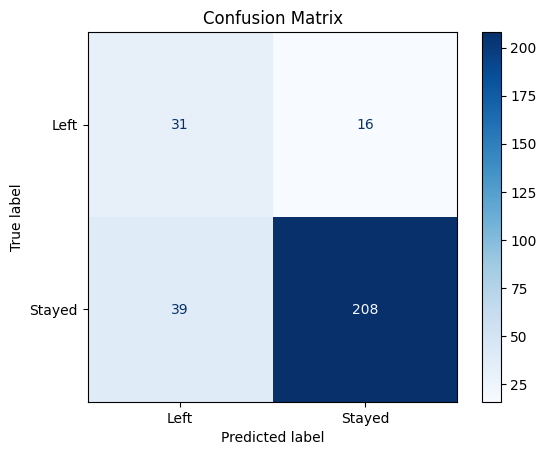

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


svc = joblib.load("est_svc.pkl")

preds = svc.predict(X_test)

cm = confusion_matrix(
    y_test,
    preds,
    labels=[1,0]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Left","Stayed"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()